In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
 ! pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [3]:
! python -m pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd
xls=pd.ExcelFile("QVI_transaction_data.xlsx")
print(xls.sheet_names)

['in']


In [5]:
transaction_data=pd.read_excel("QVI_transaction_data.xlsx")
purchase_behaviour=pd.read_csv("QVI_purchase_behaviour.csv")


In [6]:
purchase_behaviour.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [7]:
transaction_data["DATE"]=pd.to_datetime(transaction_data["DATE"],
                                        unit="D",
                                        origin="1899-12-30")

In [8]:
transaction_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [9]:
transaction_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [10]:
transaction_data.isnull().sum()
transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [11]:
transaction_data["PROD_QTY"].describe()

count    264836.000000
mean          1.907309
std           0.643654
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [12]:
transaction_data["PROD_QTY"].value_counts().sort_index()

PROD_QTY
1       27518
2      236039
3         430
4         397
5         450
200         2
Name: count, dtype: int64

In [13]:
transaction_data["PROD_NAME"].head(10)

0      Natural Chip        Compny SeaSalt175g
1                    CCs Nacho Cheese    175g
2      Smiths Crinkle Cut  Chips Chicken 170g
3      Smiths Chip Thinly  S/Cream&Onion 175g
4    Kettle Tortilla ChpsHny&Jlpno Chili 150g
5    Old El Paso Salsa   Dip Tomato Mild 300g
6    Smiths Crinkle Chips Salt & Vinegar 330g
7       Grain Waves         Sweet Chilli 210g
8     Doritos Corn Chip Mexican Jalapeno 150g
9       Grain Waves Sour    Cream&Chives 210G
Name: PROD_NAME, dtype: str

In [14]:
transaction_data["PROD_NAME"].value_counts().head(15)

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Tostitos Splash Of  Lime 175g               3252
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Kettle Sensations   Camembert & Fig 150g    3219
Doritos Corn Chips  Cheese Supreme 170g     3217
Pringles Barbeque   134g                    3210
Doritos Corn Chip Mexican Jalapeno 150g     3204
Kettle Sweet Chilli And Sour Cream 175g     3200
Name: count, dtype: int64

In [15]:
transaction_data["PACK_SIZE"]=transaction_data["PROD_NAME"].str.extract(r'(\d+g)')

In [16]:
transaction_data.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE'],
      dtype='str')

In [17]:
transaction_data[["PROD_NAME","PACK_SIZE"]].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175g
1,CCs Nacho Cheese 175g,175g
2,Smiths Crinkle Cut Chips Chicken 170g,170g
3,Smiths Chip Thinly S/Cream&Onion 175g,175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150g
5,Old El Paso Salsa Dip Tomato Mild 300g,300g
6,Smiths Crinkle Chips Salt & Vinegar 330g,330g
7,Grain Waves Sweet Chilli 210g,210g
8,Doritos Corn Chip Mexican Jalapeno 150g,150g
9,Grain Waves Sour Cream&Chives 210G,NaN


In [18]:
transaction_data["PACK_SIZE"].value_counts().sort_index()

PACK_SIZE
110g    22387
125g     1454
134g    25102
135g     3257
150g    41633
160g     2970
165g    15297
170g    19983
175g    64929
180g     1468
190g     2995
200g     4473
210g     3167
220g     1564
250g     3169
270g     6285
300g    15166
330g    12540
380g     6418
70g      1507
90g      3008
Name: count, dtype: int64

In [19]:
transaction_data["PROD_NAME"].head(30)

0       Natural Chip        Compny SeaSalt175g
1                     CCs Nacho Cheese    175g
2       Smiths Crinkle Cut  Chips Chicken 170g
3       Smiths Chip Thinly  S/Cream&Onion 175g
4     Kettle Tortilla ChpsHny&Jlpno Chili 150g
5     Old El Paso Salsa   Dip Tomato Mild 300g
6     Smiths Crinkle Chips Salt & Vinegar 330g
7        Grain Waves         Sweet Chilli 210g
8      Doritos Corn Chip Mexican Jalapeno 150g
9        Grain Waves Sour    Cream&Chives 210G
10    Smiths Crinkle Chips Salt & Vinegar 330g
11       Kettle Sensations   Siracha Lime 150g
12                    Twisties Cheese     270g
13            WW Crinkle Cut      Chicken 175g
14              Thins Chips Light&  Tangy 175g
15                           CCs Original 175g
16                           Burger Rings 220g
17      NCC Sour Cream &    Garden Chives 175g
18     Doritos Corn Chip Southern Chicken 150g
19                    Cheezels Cheese Box 125g
20           Smiths Crinkle      Original 330g
21      NCC S

In [20]:
transaction_data["BRAND"]=transaction_data["PROD_NAME"].str.split().str[0]

In [21]:
transaction_data["BRAND"]

0          Natural
1              CCs
2           Smiths
3           Smiths
4           Kettle
            ...   
264831      Kettle
264832    Tostitos
264833     Doritos
264834     Doritos
264835    Tostitos
Name: BRAND, Length: 264836, dtype: object

In [22]:
transaction_data["BRAND"].value_counts()

BRAND
Kettle        41288
Smiths        28860
Pringles      25102
Doritos       24962
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Old            9324
Tyrrells       6442
Grain          6272
Natural        6050
Red            5885
Cheezels       4603
CCs            4551
Woolworths     4437
Dorito         3185
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

In [23]:
transaction_data["BRAND"].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Old', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'Woolworths', 'French', 'RRD', 'Tostitos',
       'Cheetos', 'Snbts', 'Sunbites'], dtype=object)

In [24]:
transaction_data["PROD_NAME"]

0           Natural Chip        Compny SeaSalt175g
1                         CCs Nacho Cheese    175g
2           Smiths Crinkle Cut  Chips Chicken 170g
3           Smiths Chip Thinly  S/Cream&Onion 175g
4         Kettle Tortilla ChpsHny&Jlpno Chili 150g
                            ...                   
264831     Kettle Sweet Chilli And Sour Cream 175g
264832               Tostitos Splash Of  Lime 175g
264833                    Doritos Mexicana    170g
264834     Doritos Corn Chip Mexican Jalapeno 150g
264835               Tostitos Splash Of  Lime 175g
Name: PROD_NAME, Length: 264836, dtype: str

In [25]:
transaction_data["BRAND"]=transaction_data["BRAND"].replace({
    "Natural":"Natural Chip Company",
    "Old":"Old EI Paso",
    "Grain":"Grain Waves",
    "Red":"Red Rock Deli",
    



})

In [26]:
transaction_data["BRAND"].head(30)

0     Natural Chip Company
1                      CCs
2                   Smiths
3                   Smiths
4                   Kettle
5              Old EI Paso
6                   Smiths
7              Grain Waves
8                  Doritos
9              Grain Waves
10                  Smiths
11                  Kettle
12                Twisties
13                      WW
14                   Thins
15                     CCs
16                  Burger
17                     NCC
18                 Doritos
19                Cheezels
20                  Smiths
21                     NCC
22                  Infzns
23                  Kettle
24                  Kettle
25             Old EI Paso
26                  Smiths
27                  Kettle
28           Red Rock Deli
29                  Infzns
Name: BRAND, dtype: object

In [27]:
transaction_data[transaction_data["BRAND"]=="Burger"]["PROD_NAME"]

16        Burger Rings 220g
187       Burger Rings 220g
303       Burger Rings 220g
537       Burger Rings 220g
564       Burger Rings 220g
                ...        
264458    Burger Rings 220g
264539    Burger Rings 220g
264617    Burger Rings 220g
264692    Burger Rings 220g
264700    Burger Rings 220g
Name: PROD_NAME, Length: 1564, dtype: str

In [28]:
transaction_data[transaction_data["BRAND"]=="NCC"]["PROD_NAME"]

17        NCC Sour Cream &    Garden Chives 175g
21        NCC Sour Cream &    Garden Chives 175g
437       NCC Sour Cream &    Garden Chives 175g
535       NCC Sour Cream &    Garden Chives 175g
828       NCC Sour Cream &    Garden Chives 175g
                           ...                  
264307    NCC Sour Cream &    Garden Chives 175g
264360    NCC Sour Cream &    Garden Chives 175g
264636    NCC Sour Cream &    Garden Chives 175g
264721    NCC Sour Cream &    Garden Chives 175g
264742    NCC Sour Cream &    Garden Chives 175g
Name: PROD_NAME, Length: 1419, dtype: str

In [29]:
transaction_data[transaction_data["BRAND"]=="Infzns"]["PROD_NAME"]

22        Infzns Crn Crnchers Tangy Gcamole 110g
29        Infzns Crn Crnchers Tangy Gcamole 110g
46        Infzns Crn Crnchers Tangy Gcamole 110g
175       Infzns Crn Crnchers Tangy Gcamole 110g
180       Infzns Crn Crnchers Tangy Gcamole 110g
                           ...                  
264279    Infzns Crn Crnchers Tangy Gcamole 110g
264327    Infzns Crn Crnchers Tangy Gcamole 110g
264392    Infzns Crn Crnchers Tangy Gcamole 110g
264582    Infzns Crn Crnchers Tangy Gcamole 110g
264783    Infzns Crn Crnchers Tangy Gcamole 110g
Name: PROD_NAME, Length: 3144, dtype: str

In [30]:
transaction_data["BRAND"].value_counts().head(20)

BRAND
Kettle                  41288
Smiths                  28860
Pringles                25102
Doritos                 24962
Thins                   14075
RRD                     11894
Infuzions               11057
WW                      10320
Cobs                     9693
Tostitos                 9471
Twisties                 9454
Old EI Paso              9324
Tyrrells                 6442
Grain Waves              6272
Natural Chip Company     6050
Red Rock Deli            5885
Cheezels                 4603
CCs                      4551
Woolworths               4437
Dorito                   3185
Name: count, dtype: int64

In [31]:
transaction_data.shape

(264836, 10)

In [32]:
transaction_data["LYLTY_CARD_NBR"].nunique()

72637

In [33]:
merged_data=transaction_data.merge(purchase_behaviour,on="LYLTY_CARD_NBR",how="left")

In [34]:
merged_data.shape

(264836, 12)

In [35]:
merged_data["LIFESTAGE"].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54479
RETIREES                  49763
OLDER FAMILIES            48596
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

In [36]:
merged_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175g,Natural Chip Company,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,300g,Old EI Paso,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330g,Smiths,MIDAGE SINGLES/COUPLES,Budget
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210g,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150g,Doritos,MIDAGE SINGLES/COUPLES,Budget
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,NaN,Grain Waves,MIDAGE SINGLES/COUPLES,Budget


In [37]:
merged_data["LIFESTAGE"].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54479
RETIREES                  49763
OLDER FAMILIES            48596
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

In [38]:
merged_data["PREMIUM_CUSTOMER"].value_counts()

PREMIUM_CUSTOMER
Mainstream    101988
Budget         93157
Premium        69691
Name: count, dtype: int64

In [39]:
merged_data["BRAND"].value_counts().head(10)

BRAND
Kettle       41288
Smiths       28860
Pringles     25102
Doritos      24962
Thins        14075
RRD          11894
Infuzions    11057
WW           10320
Cobs          9693
Tostitos      9471
Name: count, dtype: int64

In [40]:
merged_data.groupby(
    ["LIFESTAGE","PREMIUM_CUSTOMER"]
    )
merged_data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"]


In [41]:
merged_data["TOT_SALES"].dtype

dtype('float64')

In [42]:
grp=merged_data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])

In [43]:
sales_by_group=grp["TOT_SALES"].sum()

In [44]:
sales_by_group.sort_values(ascending=False)

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              168363.25
YOUNG SINGLES/COUPLES   Mainstream          157621.60
RETIREES                Mainstream          155677.05
YOUNG FAMILIES          Budget              139345.85
OLDER SINGLES/COUPLES   Budget              136769.80
                        Mainstream          133393.80
                        Premium             132263.15
RETIREES                Budget              113147.80
OLDER FAMILIES          Mainstream          103445.55
RETIREES                Premium              97646.05
YOUNG FAMILIES          Mainstream           92788.75
MIDAGE SINGLES/COUPLES  Mainstream           90803.85
YOUNG FAMILIES          Premium              84025.50
OLDER FAMILIES          Premium              81958.40
YOUNG SINGLES/COUPLES   Budget               61141.60
MIDAGE SINGLES/COUPLES  Premium              58432.65
YOUNG SINGLES/COUPLES   Premium              41642.10
MIDAGE SINGLES/COUPLES  Budget           

In [45]:
merged_data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"]

In [46]:
merged_data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget               35514.80
                        Mainstream           90803.85
                        Premium              58432.65
NEW FAMILIES            Budget               21928.45
                        Mainstream           17013.90
                        Premium              11491.10
OLDER FAMILIES          Budget              168363.25
                        Mainstream          103445.55
                        Premium              81958.40
OLDER SINGLES/COUPLES   Budget              136769.80
                        Mainstream          133393.80
                        Premium             132263.15
RETIREES                Budget              113147.80
                        Mainstream          155677.05
                        Premium              97646.05
YOUNG FAMILIES          Budget              139345.85
                        Mainstream           92788.75
                        Premium          

In [47]:
merged_data["LIFESTAGE"].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54479
RETIREES                  49763
OLDER FAMILIES            48596
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

In [48]:
purchase_behaviour["LIFESTAGE"].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [49]:
merged_data[["LIFESTAGE","PREMIUM_CUSTOMER"]].drop_duplicates()

,LIFESTAGE,PREMIUM_CUSTOMER
0,YOUNG SINGLES/COUPLES,Premium
1,MIDAGE SINGLES/COUPLES,Budget
5021,MIDAGE SINGLES/COUPLES,Mainstream
16895,MIDAGE SINGLES/COUPLES,Premium
25111,NEW FAMILIES,Budget
28116,NEW FAMILIES,Mainstream
30441,NEW FAMILIES,Premium
32030,OLDER FAMILIES,Budget
55190,OLDER FAMILIES,Mainstream
69434,OLDER FAMILIES,Premium


In [50]:
merged_data[["LYLTY_CARD_NBR","LIFESTAGE","PREMIUM_CUSTOMER"]].head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1307,MIDAGE SINGLES/COUPLES,Budget
2,1343,MIDAGE SINGLES/COUPLES,Budget
3,2373,MIDAGE SINGLES/COUPLES,Budget
4,2426,MIDAGE SINGLES/COUPLES,Budget
5,4074,MIDAGE SINGLES/COUPLES,Budget
6,4149,MIDAGE SINGLES/COUPLES,Budget
7,4196,MIDAGE SINGLES/COUPLES,Budget
8,5026,MIDAGE SINGLES/COUPLES,Budget
9,7150,MIDAGE SINGLES/COUPLES,Budget


In [51]:
grp=merged_data.groupby("BRAND")
grp["TOT_SALES"].sum()

BRAND
Burger                    6831.0
CCs                      18078.9
Cheetos                  16884.5
Cheezels                 40029.9
Cobs                     70569.8
Dorito                   40352.0
Doritos                 201538.9
French                    7929.0
Grain Waves              43048.8
GrnWves                   8568.4
Infuzions                76247.6
Infzns                   22800.0
Kettle                  390239.8
NCC                       8046.0
Natural Chip Company     34272.0
Old EI Paso              90785.1
Pringles                177655.5
RRD                      64954.5
Red Rock Deli            30091.5
Smith                    14583.4
Smiths                  210076.8
Snbts                     5076.2
Sunbites                  4600.2
Thins                    88852.5
Tostitos                 79789.6
Twisties                 81522.1
Tyrrells                 51647.4
WW                       35889.5
Woolworths               13454.1
Name: TOT_SALES, dtype: float64

In [52]:
sales_by_group=merged_data.groupby("BRAND")
sales_by_group["TOT_SALES"].sum()

BRAND
Burger                    6831.0
CCs                      18078.9
Cheetos                  16884.5
Cheezels                 40029.9
Cobs                     70569.8
Dorito                   40352.0
Doritos                 201538.9
French                    7929.0
Grain Waves              43048.8
GrnWves                   8568.4
Infuzions                76247.6
Infzns                   22800.0
Kettle                  390239.8
NCC                       8046.0
Natural Chip Company     34272.0
Old EI Paso              90785.1
Pringles                177655.5
RRD                      64954.5
Red Rock Deli            30091.5
Smith                    14583.4
Smiths                  210076.8
Snbts                     5076.2
Sunbites                  4600.2
Thins                    88852.5
Tostitos                 79789.6
Twisties                 81522.1
Tyrrells                 51647.4
WW                       35889.5
Woolworths               13454.1
Name: TOT_SALES, dtype: float64

In [53]:
brand_group=merged_data.groupby("BRAND")


In [54]:
brand_sales=brand_group["TOT_SALES"].sum()

In [55]:
brand_sales=brand_sales.sort_values(ascending=False)

<Axes: title={'center': 'Total Sales by Brand'}, xlabel='BRAND'>

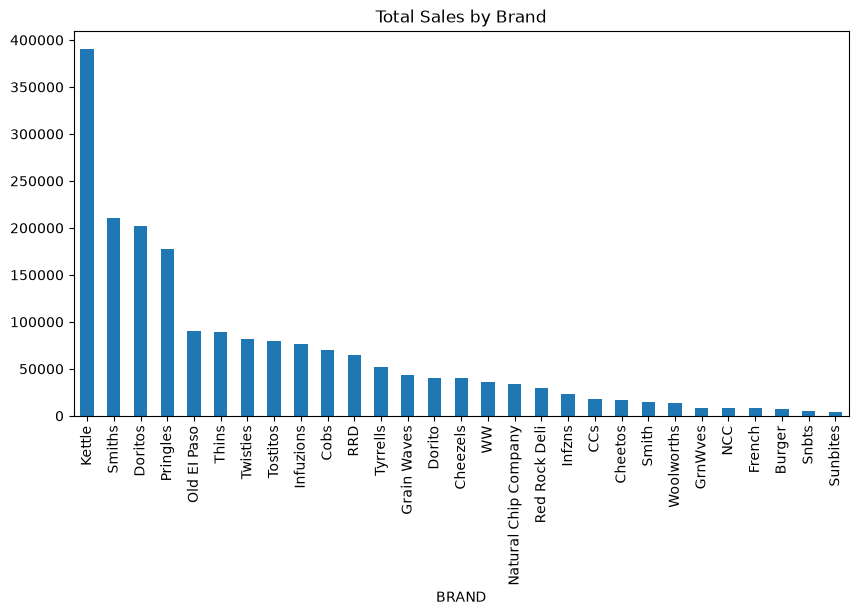

In [56]:
brand_sales.plot(kind="bar",figsize=(10,5),
                 title="Total Sales by Brand")

In [57]:
purchase_behaviour.shape

(72637, 3)

In [58]:
purchase_behaviour.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [59]:
purchase_behaviour["LYLTY_CARD_NBR"].nunique()

72637

In [60]:
purchase_behaviour["LIFESTAGE"].unique()

<StringArray>
[ 'YOUNG SINGLES/COUPLES',         'YOUNG FAMILIES',  'OLDER SINGLES/COUPLES',
 'MIDAGE SINGLES/COUPLES',           'NEW FAMILIES',         'OLDER FAMILIES',
               'RETIREES']
Length: 7, dtype: str

In [61]:
purchase_behaviour["LIFESTAGE"].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

<Axes: title={'center': 'Total Sales by Lifestage'}, xlabel='LIFESTAGE'>

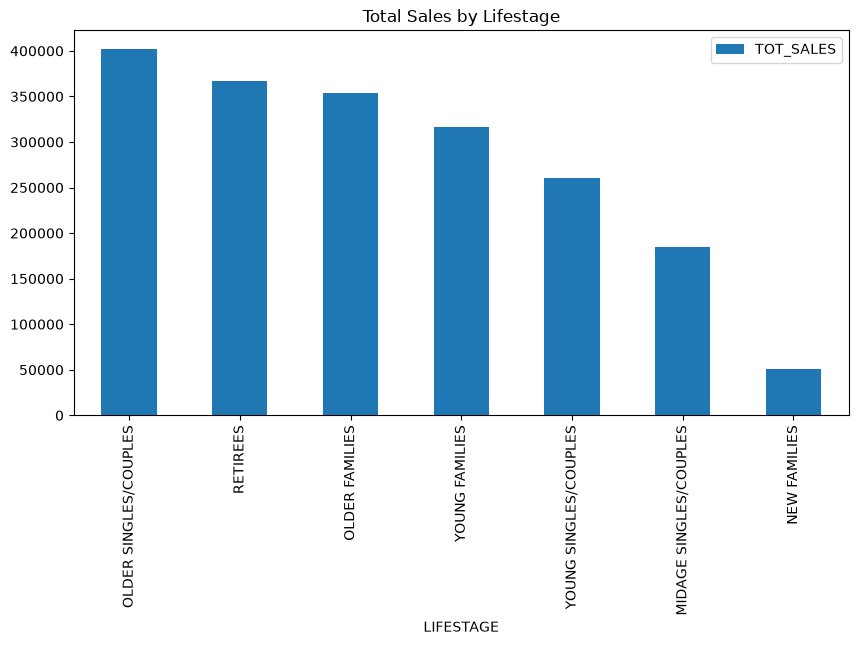

In [62]:
lifestage_group = merged_data.groupby("LIFESTAGE")

lifestage_sales = lifestage_group["TOT_SALES"].sum()

lifestage_sales = lifestage_sales.sort_values(ascending=False)

lifestage_sales.plot(kind="bar", figsize=(10,5), title="Total Sales by Lifestage",legend="False")

In [63]:
merged_data.shape

(264836, 12)

In [64]:
merged_data["LIFESTAGE"].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54479
RETIREES                  49763
OLDER FAMILIES            48596
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

<Axes: title={'center': 'Total Sales by Premium Customer'}, xlabel='PREMIUM_CUSTOMER'>

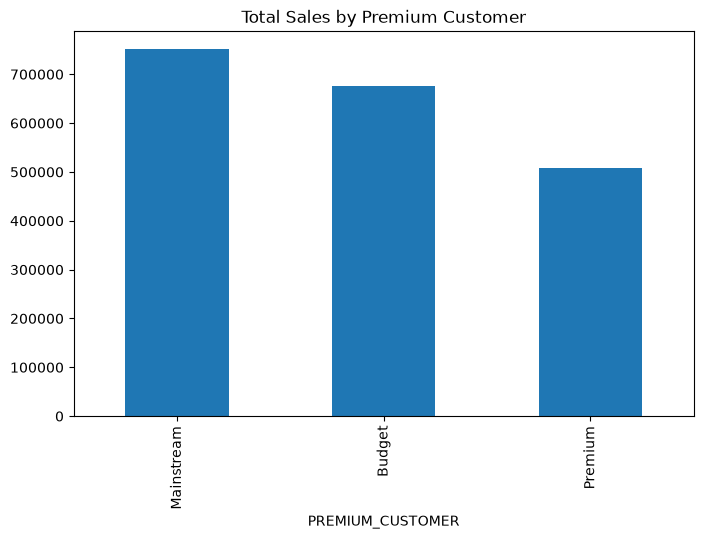

In [65]:
premium_group = merged_data.groupby("PREMIUM_CUSTOMER")

premium_sales = premium_group["TOT_SALES"].sum()

premium_sales = premium_sales.sort_values(ascending=False)

premium_sales.plot(kind="bar", figsize=(8,5), title="Total Sales by Premium Customer")